First cell: we filter stars by astrometric quality, derive physical quantities (distance, absolute magnitude), and loads astrophysical parameters (teff, logg, metallicity) from Gaia's GSP-Phot pipeline for use as ML features. We produce a Color-Magnitude Diagram (observational equivalent of an HR diagram) using two different color indices side by side.

321302 20


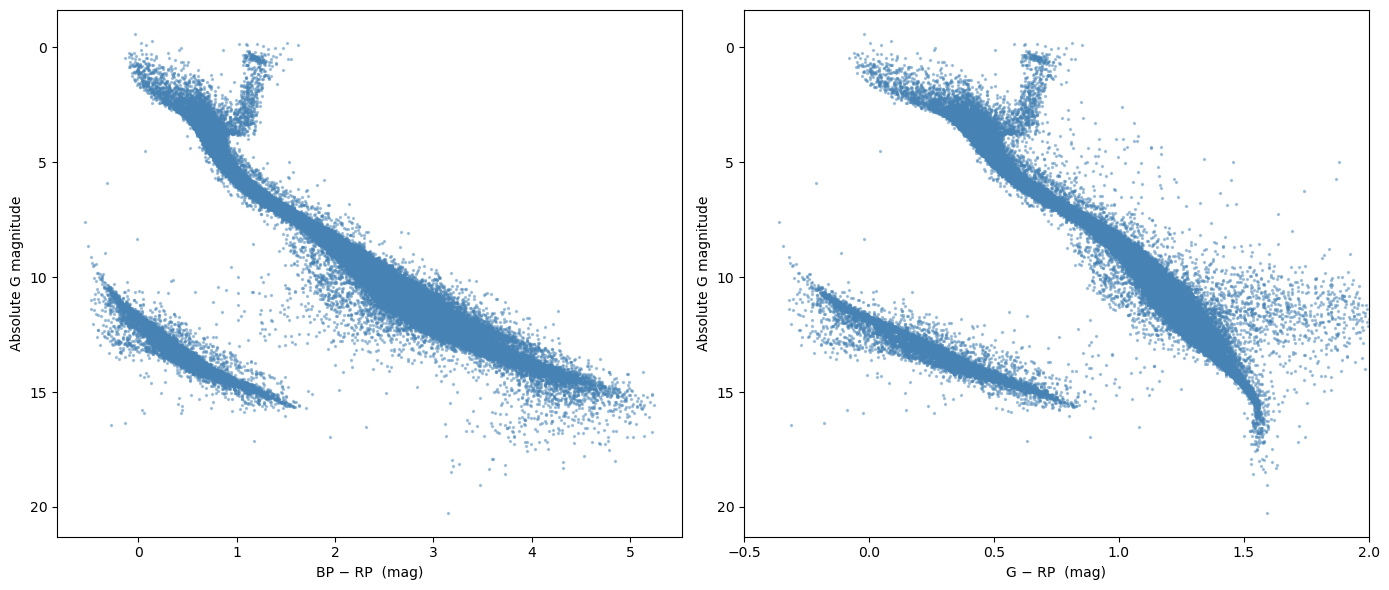

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load Gaia star catalog CSV and print number of rows (stars) and columns (features)
df = pd.read_csv("LolaQuery2-result.csv")
print(df.shape[0], df.shape[1])

# Create a boolean mask keeping only high-quality stars
# parallax_over_error > 100 => parallax measurement is very precise (signal-to-noise > 100)
# ruwe < 1.05 => the astrometric fit is clean (RUWE ≈ 1.0 means a well-behaved single star)
id = (df['parallax_over_error'] > 100) & (df['ruwe'] < 1.05) 

# Compute distance in parsec from parallax in mas
# Convert parallax (in milliarcseconds) to distance in parsecs using d = 1/π
df["dist_pc"]  = 1000.0 / df["parallax"]

# Compute absolute magnitude in G band (abs_g) from apparent magnitude ("phot_g_mean_mag") and distance modulus
# Compute the distance modulus and use it to convert apparent G-band magnitude to absolute magnitude (= what each star's brightness would be at a standard 10 pc distance)
distMod= 5.0 -5.0 * np.log10(1000/df['parallax']) 
df["abs_g"]    = df["phot_g_mean_mag"] + distMod

# The absolute magnitude is the apparent magnitude the star would have if it were all located at a distance of 10 parsec
# Keep only the quality-filtered stars for plotting
df = df[id]

# Plot Two Color-Magnitude Diagrams (CMDs)
# Two side-by-side Hertzsprung-Russell style diagrams, both with absolute G magnitude on the Y-axis (inverted, brighter = up)
fig, axs = plt.subplots(1,2,figsize=(14, 6))
ax=axs[0]
ax.scatter(df["bp_rp"], df["abs_g"], s=2, alpha=0.4, c="steelblue")
ax.invert_yaxis()
ax.set_xlabel("BP − RP  (mag)")
ax.set_ylabel("Absolute G magnitude")
#ax.set_title("Color-Magnitude Diagram — Gaia DR3 stars within 50 pc")

ax=axs[1]
ax.scatter(df["g_rp"], df["abs_g"], s=2, alpha=0.4, c="steelblue")
ax.invert_yaxis()
ax.set_xlabel("G − RP  (mag)")
ax.set_xlim(-0.5, 2.)
ax.set_ylabel("Absolute G magnitude")
#ax.set_title("Color-Magnitude Diagram — Gaia DR3 stars within 50 pc")
plt.tight_layout()
plt.savefig("color_magnitude_diagram_100pc_scatter.pdf", dpi=300)

This is a Hertzsprung-Russell (HR) diagram. We load ~321,000 stars (raw count before quality filter). After quality filters are applied (parallax_over_error > 100 and ruwe < 1.05), only 100,640 stars remain and are actually plotted.

What we see: 

1) Main sequence (= diagonal band): the dominant diagonal strip running from top-left to bottom-right is the Main Sequence = stars that are actively fusing hydrogen in their cores (like the Sun).
    - Top-left (bright & blue, BP−RP ≈ −0.3, abs_G ≈ 0–2): Hot, massive O and B-type stars = rare but very luminous
    - Middle (abs_G ≈ 4–5, BP−RP ≈ 0.6–0.8): G-type stars like the Sun (our Sun sits around abs_G ≈ 4.8)
    - Bottom-right (faint & red, BP−RP > 2): Cool, dim M-dwarf red dwarfs = the most numerous stars in the galaxy
      
2) Giant Branch (upper-right clump & plume): the cluster of stars at the top-right (bright but red, abs_G ≈ 0–3, BP−RP ≈ 1–2) are red giants and subgiants = stars that have exhausted their core hydrogen and expanded enormously.
- A subgiant branch peeling off the main sequence around abs_G ≈ 3–4
- The Red Giant Branch (RGB) curving upward-right
- A dense clump around BP−RP ≈ 1, abs_G ≈ 0.5: the Red Clump = low-mass stars in a stable helium-burning phase, used as standard candles in astronomy

3) The White Dwarf Sequence (bottom-left): the separate, isolated cloud of points at bottom-left (faint but blue/white, abs_G ≈ 10–16, BP−RP ≈ −0.5 to 0.5) are white dwarfs = the hot, dense remnants of dead stars. They're clearly separated from the main sequence, forming their own distinct sequence.

Left vs Right Plot: 

The two panels show the same stars with different color indices:
1) Left (BP-RP): 
- Range: −0.5 to ~5.5;
- Sensitivity: Broad optical range
- White dwarfs: More spread out;
- Red stars: Extended to BP−RP > 4

2) Right (G−RP):
- Range: −0.5 to 2.0;
- Sensitivity: Red-sensitive;
- White dwarfs: Compressed, cleaner separation;
- Red stars: Clipped at G−RP = 2 by xlim

In [19]:
plot_2d_correl=True
nbinx,nbiny = 150,150

#  xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines
correl=    ([
      (f'Color (Bp - Rp)', ''      , f'bp_rp'      ,'linear',-1.,6,[]),
      (f'Color (G - Rp)', ''       , f'g_rp'       ,'linear',-0.5,2.,[]),
      (f'Color (Bp - G)', ''      , f'bp_g'      ,'linear',-0.5,4,[]),],
    [
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21.,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21,[]),
        ]
)
title='Color-Magnitude Diagrams — Gaia DR3 stars within 100 pc'

This defines 3 Color-Magnitude Diagrams side by side, each using a different color index on the X-axis but the same luminosity axis on Y. The vlines=[] entries leave room to optionally draw vertical reference lines on any panel.

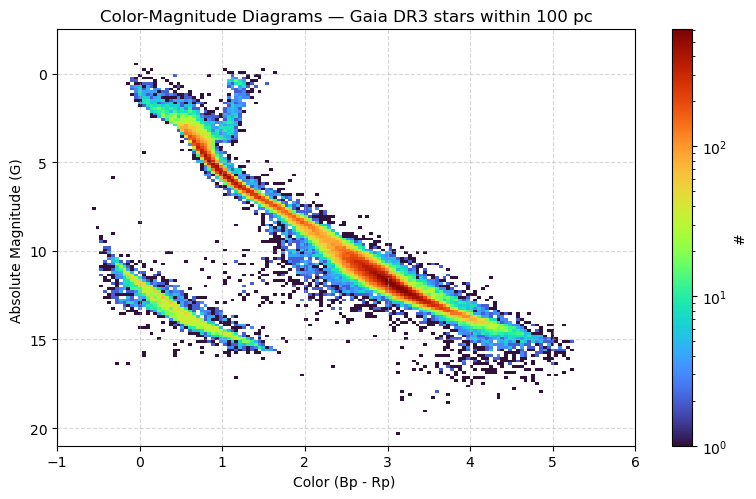

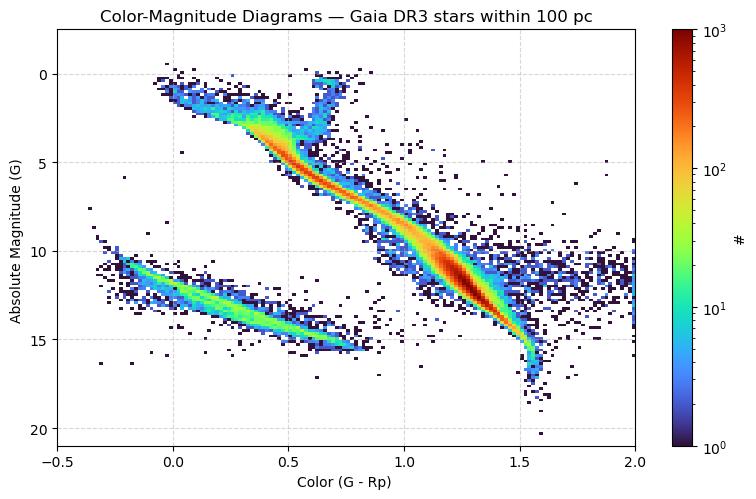

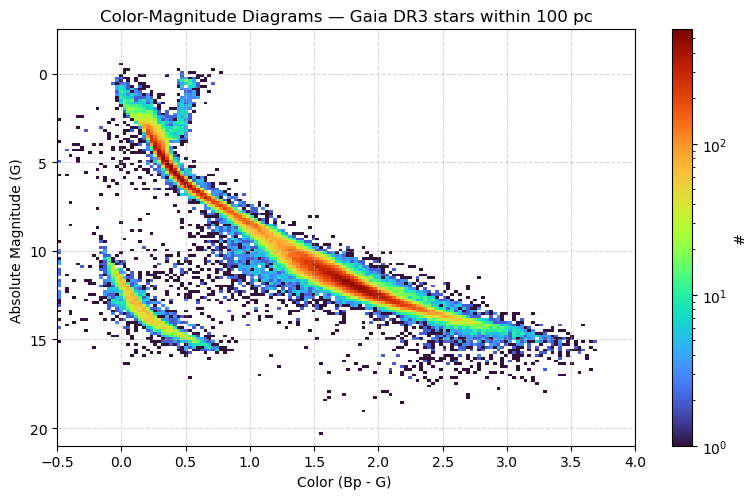

In [21]:
# we iterate over the 3 paired (X-config, Y-config) tuples simultaneously
for xs, ys in zip(correl[0],correl[1]):
    # we extract all axis parameters for this particular plot
    xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines=xs
    ykeylbl,ykeyunit,ykey, yscale, ymin, ymax, hlines=ys      
    count=0
    # If no range was hardcoded, it automatically computes the 1st–99th percentile range from the data, avoiding extreme outliers stretching the axis
    if xmin is None:
        xmin, xmax = np.quantile(df[xkey], [0.01, 0.99])
    if ymin is None:
        ymin, ymax = np.quantile(df[ykey], [0.01, 0.99])

    fig, ax = plt.subplots(
    1,1, figsize=(8, 5.1)
    )
    ax.set_title(title
      #f'{crit}\n rem. {np.sum(keep)}  (filt. {np.sum(~ind)}, {uniq} unique)'
    )
    # hist2d bins all 321k stars into a 150×150 grid and colors each cell by star count
    # norm='log': log-scaled color so both sparse (white dwarfs) and dense (main sequence) regions are visible simultaneously
    # cmap='turbo': uniform colormap 
    # rasterized=True: renders the dense pixel grid as a bitmap inside the PDF, keeping file size small
    # Log or linear bins: chosen dynamically based on xscale/yscale from config
    _, _, _, im = ax.hist2d(         
      df.loc[:, xkey].clip(xmin, xmax),
      df.loc[:, ykey].clip(ymin, ymax),
      bins=(
        10 ** np.linspace(np.log10(xmin), np.log10(xmax), nbinx + 1)
        if xscale == 'log'
        else np.linspace(xmin, xmax, nbinx + 1),
        10 ** np.linspace(np.log10(ymin), np.log10(ymax), nbiny + 1)
        if yscale == 'log'
        else np.linspace(ymin, ymax, nbiny + 1),
      ),
      cmap='turbo',
      norm='log',
      rasterized=True,
    )
    vmin, vmax = im.norm.vmin, im.norm.vmax
    #print(f'check Density plot (vmin,vmax)=({vmin}, {vmax})')
    # Adds a color legend showing star counts per bin, but only if the histogram is non-empty
    if vmin!=0 and vmax!=0:
      fig.colorbar(im, ax=ax, label='#')
    ax.set_xlabel(f'{xkeylbl} {xkeyunit}')
    ax.set_ylabel(f'{ykeylbl} {ykeyunit}')
    # Y-axis inverted if plotting absolute magnitude (brighter stars = top)
    if xscale == 'log':
      ax.set_xscale('log')
    if yscale == 'log':
      ax.set_yscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    #plt.title(f'{ykeylbl}_vs_{xkeylbl}')
    ax.grid(which='both', linestyle='--', alpha=0.5)
    if ykey=='abs_g':
        ax.invert_yaxis()

      
    fig.tight_layout()
    fig.savefig(f'color_magnitude_diagram_100pc_{ykey}_vs_{xkey}.pdf')

#    figsaved=fig.copy()
#    axsaved=ax.copy()


Plot 1: BP−RP vs Absolute G Magnitude
--> This is the broadest color index, spanning the full optical range from blue (BP) to red (RP).

1. Main Sequence (long diagonal, top-left to bottom-right):
- Runs from BP−RP ≈ −0.3 (hot blue stars, abs_G ≈ 0) all the way to BP−RP ≈ 5 (cool red dwarfs, abs_G ≈ 16)
- The densest red core sits around BP−RP ≈ 3–4, abs_G ≈ 11–12 — K/M dwarfs, the most common stars in the solar neighbourhood
- The sequence is the longest and most diagonal of the three plots because BP−RP covers the widest wavelength baseline

2. Giant Branch (upper-right clump):
- The bright fork at top (abs_G ≈ 0–2, BP−RP ≈ 1–1.5) shows the red giant branch tip and AGB
- A horizontal extension to the left around abs_G ≈ 0 traces hot supergiants and bright giants
- The two "horns" are clearly visible --> RGB tip and AGB diverging
-
White Dwarf Sequence (bottom-left island):
- Sits at BP−RP ≈ −0.5 to 0.3, abs_G ≈ 10–15
- Well separated from the main sequence
- Appears relatively spread out horizontally in this index compared to the other two plots => BP−RP is less efficient at compressing the white dwarf temperature sequence
  
=> Colorbar peaks at ~10² (around 100 stars/bin), lower than Plot 2, because the wider x-axis spreads stars across more bins

Plot 2: G−RP vs Absolute G Magnitude
--> This uses only the red half of the spectrum (G minus RP), giving the most compressed x-axis (−0.5 to 2.0).

1. Main Sequence:
- Still runs diagonally but is more compressed horizontally; the entire sequence fits in just 2 magnitudes of color
The densest core (deep red) sits around G−RP ≈ 0.8–1.0, abs_G ≈ 10–11
- The sequence appears wider and fluffier than in the other plots. G−RP is less discriminating for hot blue stars, so the upper main sequence fans out
The bottom of the sequence curves noticeably rightward at abs_G > 13, tracing the M-dwarf knee where molecular absorption changes the spectral shape

2. Giant Branch:
- The bright fork at top (abs_G ≈ 0–2, G−RP ≈ 0.3–0.7) is well defined
- Notably the giants and upper main sequence are more separated here than in BP−RP; the red-sensitive index distinguishes evolved stars well
- The colorbar peaks at 10³ (over 1,000 stars/bin), which is the highest density of the three plots, because all stars are compressed into a narrow x-range

3. White Dwarf Sequence:
- Sits at G−RP ≈ −0.3 to 0.2, abs_G ≈ 10–14
- This is the cleanest separation from the main sequence of the three plots. There's a visible gap between the WD arc and the bottom of the main sequence
- The arc is tight and well-defined, making G−RP particularly good for identifying white dwarfs

Plot 3: P−G vs Absolute G Magnitude
--> This uses blue minus broad-green, making it most sensitive to the hotter, bluer part of the spectrum.

1. Main Sequence:
- Runs from BP−G ≈ 0 (hot stars, abs_G ≈ 2) to BP−G ≈ 3.7 (cool red dwarfs, abs_G ≈ 15)
- This is the most diagonally stretched of the three sequences: BP−G has the best leverage for separating stellar types across temperature
- The dense red core sits around BP−G ≈ 2, abs_G ≈ 11 --> same K/M dwarf population, just shifted in color
- The sequence is narrow and sharp for solar-type stars, then broadens noticeably below abs_G ≈ 12 where M-dwarf molecular bands start affecting BP more than G

2. Giant Branch:
- The two-horned fork at top (abs_G ≈ −2 to 2, BP−G ≈ 0 to 0.5) is the most visually dramatic of the three plots
- The two prongs are the RGB tip and AGB diverging; especially clear here because BP−G is sensitive to the slight temperature difference between these two populations
- A horizontal spur of blue/cyan points extends left around abs_G ≈ 0, tracing rare hot luminous stars

3. White Dwarf Sequence:
- Sits at BP−G ≈ −0.3 to 0.5, abs_G ≈ 10–14
- Cleanly detached from the main sequence with a clear gap
- The arc curves slightly differently than in the other plots: BP is more affected by WD surface temperature, making the sequence tilt more steeply

=> Together the three color indices are complementary; each reveals different structure in the HR diagram, which is exactly why combining all three as features in your ML model will give it more discriminating power than any single index alone.